In [34]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ==========================================
# Load Cleaned Healthcare Dataset
# ==========================================

df = pd.read_csv("../data/processed/ckd_cleaned.csv")

# Display first rows
df.head()


,id,age,bp,sg,al,su,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,-1.727726,-0.210031,0.254214,0.421486,0.076249,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,0.603224,-0.197314,0.550044,1.311903,1.385535,-0.304789,-0.510723,-0.472690,-0.420084,0
1,-1.719066,-2.627234,-1.972476,0.421486,2.363728,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,-0.132789,-0.909782,0.074073,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084,0
2,-1.710406,0.615355,0.254214,-1.421074,0.838742,2.507853,0.484322,-0.342518,-0.241249,3.697618,...,-0.991470,-0.316059,0.074073,-0.762252,1.385535,-0.304789,1.965511,-0.472690,2.380476,0
3,-1.701745,-0.210031,-0.488016,-2.342354,2.363728,-0.380269,-2.064742,2.919556,-0.241249,-0.373337,...,-0.868801,-0.632711,-0.996862,1.311903,-0.721743,-0.304789,1.965511,2.048324,2.380476,0
4,-1.693085,-0.033163,0.254214,-1.421074,0.838742,-0.380269,0.484322,-0.342518,-0.241249,-0.519679,...,-0.500795,-0.395222,-0.163913,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084,0


In [35]:
# Dataset shape

print(df.shape)

(400, 25)


In [36]:
# Missing value check

print(df.isnull().sum())

id       0
age      0
bp       0
sg       0
al       0
su       0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64


In [37]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      400 non-null    float64
 1   age     400 non-null    float64
 2   bp      400 non-null    float64
 3   sg      400 non-null    float64
 4   al      400 non-null    float64
 5   su      400 non-null    float64
 6   pc      400 non-null    float64
 7   pcc     400 non-null    float64
 8   ba      400 non-null    float64
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    float64
 19  dm      400 non-null    float64
 20  cad     400 non-null    float64
 21  appet   400 non-null    float64
 22  pe      400 n

In [38]:
# ==========================================
# Remove Hidden Spaces From Column Names
# ==========================================

df.columns = df.columns.str.strip()

In [39]:
# ==========================================
# Identify Categorical Columns
# ==========================================

categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index([], dtype='str')


In [40]:
# ==========================================
# Initialize Label Encoder
# ==========================================

label_encoder = LabelEncoder()

# ==========================================
# Encode Categorical Features
# ==========================================

for col in categorical_cols:
    
    # Convert categorical labels into numerical values
    df[col] = label_encoder.fit_transform(df[col])

In [41]:
# ==========================================
# Display Encoded Dataset
# ==========================================

df.head()

,id,age,bp,sg,al,su,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,-1.727726,-0.210031,0.254214,0.421486,0.076249,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,0.603224,-0.197314,0.550044,1.311903,1.385535,-0.304789,-0.510723,-0.472690,-0.420084,0
1,-1.719066,-2.627234,-1.972476,0.421486,2.363728,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,-0.132789,-0.909782,0.074073,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084,0
2,-1.710406,0.615355,0.254214,-1.421074,0.838742,2.507853,0.484322,-0.342518,-0.241249,3.697618,...,-0.991470,-0.316059,0.074073,-0.762252,1.385535,-0.304789,1.965511,-0.472690,2.380476,0
3,-1.701745,-0.210031,-0.488016,-2.342354,2.363728,-0.380269,-2.064742,2.919556,-0.241249,-0.373337,...,-0.868801,-0.632711,-0.996862,1.311903,-0.721743,-0.304789,1.965511,2.048324,2.380476,0
4,-1.693085,-0.033163,0.254214,-1.421074,0.838742,-0.380269,0.484322,-0.342518,-0.241249,-0.519679,...,-0.500795,-0.395222,-0.163913,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084,0


In [42]:
df.to_csv(
    "../data/processed/ckd_encoded.csv",
    index=False
)

In [43]:
##Load encoded dataset
df = pd.read_csv("../data/processed/ckd_encoded.csv")

In [44]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = df.drop("class", axis=1)

y = df["class"]

In [45]:
# ==========================================
# Initialize StandardScaler
# ==========================================

scaler = StandardScaler()

# ==========================================
# Standardize Feature Variables
# ==========================================

X_scaled = scaler.fit_transform(X)

In [46]:
# ==========================================
# Convert Scaled Array Into DataFrame
# ==========================================

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,id,age,bp,sg,al,su,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,-1.727726,-0.210031,0.254214,0.421486,0.076249,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,1.053226,0.603224,-0.197314,0.550044,1.311903,1.385535,-0.304789,-0.510723,-0.472690,-0.420084
1,-1.719066,-2.627234,-1.972476,0.421486,2.363728,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,-0.457965,-0.132789,-0.909782,0.074073,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084
2,-1.710406,0.615355,0.254214,-1.421074,0.838742,2.507853,0.484322,-0.342518,-0.241249,3.697618,...,-1.084556,-0.991470,-0.316059,0.074073,-0.762252,1.385535,-0.304789,1.965511,-0.472690,2.380476
3,-1.701745,-0.210031,-0.488016,-2.342354,2.363728,-0.380269,-2.064742,2.919556,-0.241249,-0.373337,...,-0.494823,-0.868801,-0.632711,-0.996862,1.311903,-0.721743,-0.304789,1.965511,2.048324,2.380476
4,-1.693085,-0.033163,0.254214,-1.421074,0.838742,-0.380269,0.484322,-0.342518,-0.241249,-0.519679,...,-0.347390,-0.500795,-0.395222,-0.163913,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084


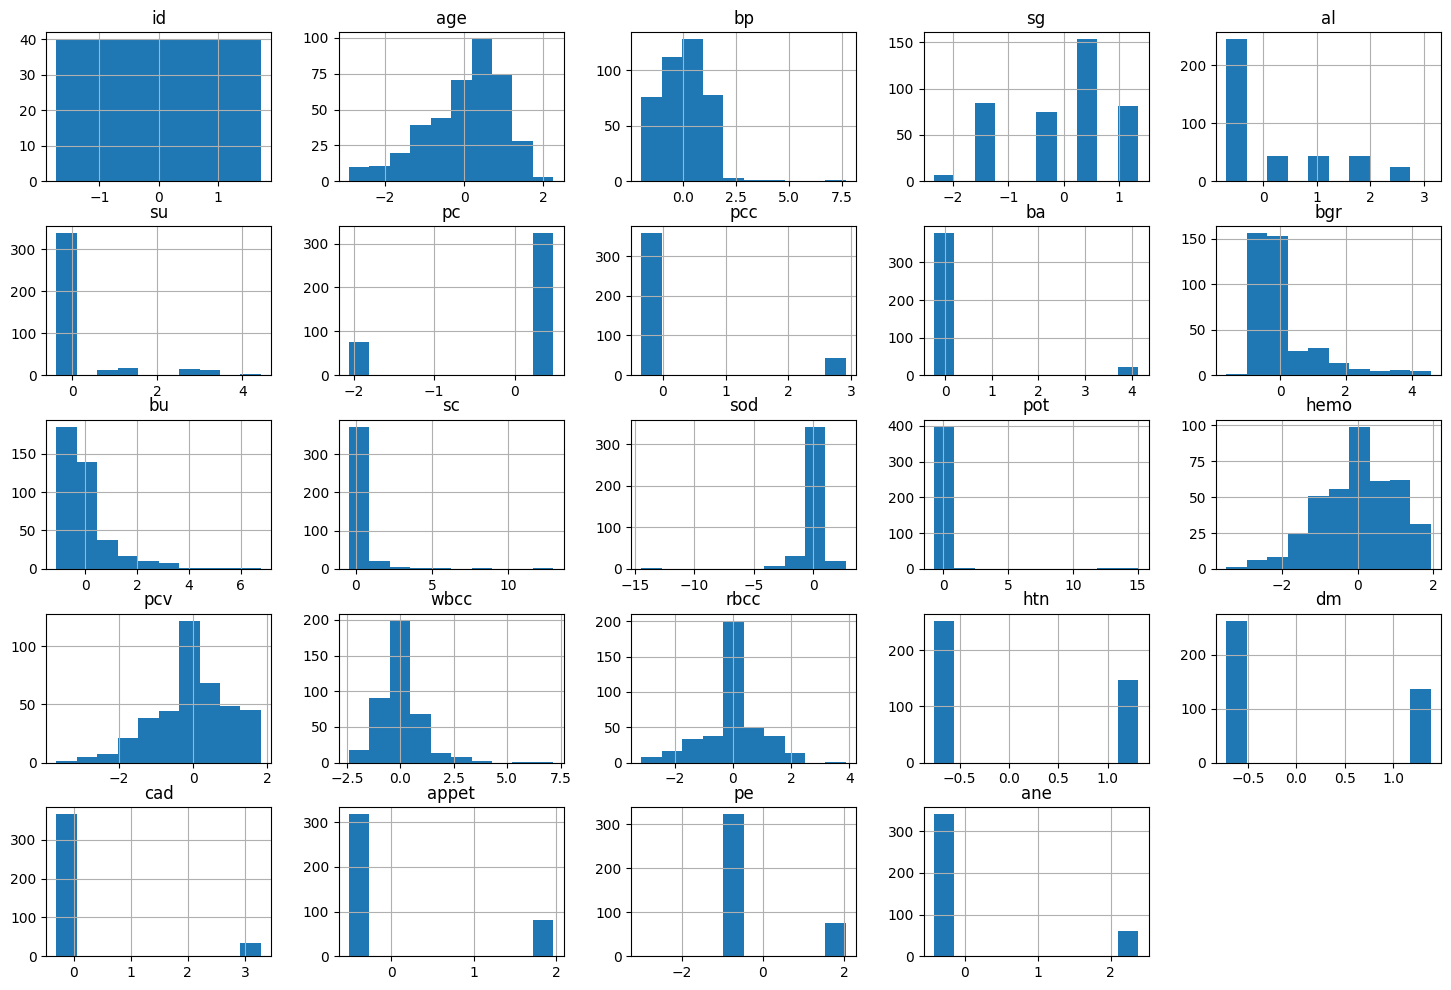

In [47]:
# ==========================================
# Feature Distribution After Standardization
# ==========================================
import matplotlib.pyplot as plt

X_scaled.hist(figsize=(18,12))

plt.show()

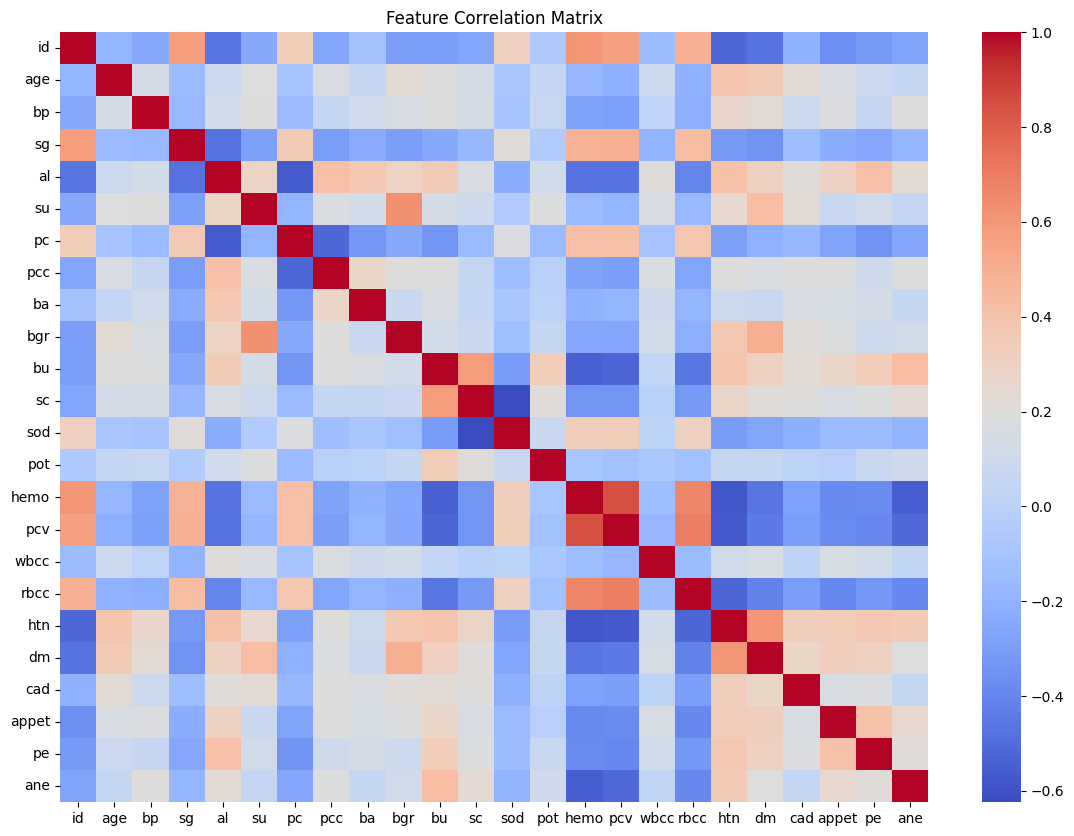

In [48]:
# ==========================================
# Correlation Matrix for Engineered Features
# ==========================================
import seaborn as sns 

plt.figure(figsize=(14,10))

sns.heatmap(
    X_scaled.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [49]:
# ==========================================
# Add Target Variable Back
# ==========================================

X_scaled["class"] = y.values

# Final dataset shape

print(X_scaled.shape)

(400, 25)


In [50]:
# Final missing value check

print(X_scaled.isnull().sum())

id       0
age      0
bp       0
sg       0
al       0
su       0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64


In [51]:
# ==========================================
# Export ML-Ready Dataset
# ==========================================

X_scaled.to_csv(
    "../data/processed/ckd_ml_ready.csv",
    index=False
)

In [52]:
#Load scaled dataset
df = pd.read_csv("../data/processed/ckd_scaled.csv")


In [53]:
#Separate features & target
X = df.drop("class", axis=1)
y = df["class"]

In [54]:
#Check Class Distribution
print(y.value_counts())

class
0    250
1    150
Name: count, dtype: int64


In [55]:
# Apply SMOTE to balance classes
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [56]:
# Verify Balanced Dataset
print(y_resampled.value_counts())

class
0    250
1    250
Name: count, dtype: int64


In [57]:
#Create Final ML Dataset
ml_ready_df = pd.DataFrame(
    X_resampled,
    columns=X.columns
)

ml_ready_df["class"] = y_resampled

In [58]:
# Remove ID Column Before Final Export

if "id" in ml_ready_df.columns:
    
    ml_ready_df = ml_ready_df.drop(
        
        "id",
        
        axis=1
    )

In [59]:
#Export Final Dataset
ml_ready_df.to_csv(
    "../data/processed/ckd_ml_ready.csv",
    index=False
)

In [60]:
print(ml_ready_df.columns.tolist())

['age', 'bp', 'sg', 'al', 'su', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'Unnamed: 26', 'class']


In [61]:
# ==========================================
# Save StandardScaler Object
# ==========================================

import joblib

joblib.dump(
    scaler,
    "../models/standard_scaler.pkl"
)

['../models/standard_scaler.pkl']

In [62]:
# ==========================================
# Final Workflow Confirmation
# ==========================================

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully
